# 🏦 Practical 2: Deep MLP for Customer Churn Prediction
## Deep Learning Lab | BTech Semester 4

---

### 🎯 Objective
Build a robust **Multi-Layer Perceptron (MLP)** for a real-world binary classification problem — predicting whether a bank customer will churn (leave the bank).

### 📌 What You Will Learn
- Real-world data preprocessing: One-Hot Encoding, Feature Scaling
- Building deep feed-forward networks (3-4 hidden layers)
- Evaluating models using industry-standard metrics: Precision, Recall, F1-Score
- Understanding class imbalance and its impact on accuracy

### 📚 References
- Goodfellow et al. — *Deep Learning* (MIT Press, 2016) — Chapter 6
- Dataset: Bank Customer Churn (https://www.kaggle.com/datasets/shantanudhakadd/bank-customer-churn-prediction)
- Scikit-learn docs: https://scikit-learn.org/stable/modules/classes.html
- TensorFlow/Keras Guide: https://www.tensorflow.org/guide/keras

---

## 📦 Step 1: Install & Import Libraries

In [1]:
# Install required packages (if running on a fresh Colab runtime)
# !pip install tensorflow scikit-learn pandas matplotlib seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                              precision_score, recall_score, f1_score)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Suppress minor warnings
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"Pandas version: {pd.__version__}")
print("All libraries imported successfully!")

TensorFlow version: 2.19.0
Pandas version: 2.2.2
All libraries imported successfully!


## 📂 Step 2: Load the Dataset

### Option A: Download from Kaggle (recommended)
Upload your `kaggle.json` API key and run the cell below.

### Option B: Use synthetic data (fallback — runs automatically)

In [2]:
# =========================================================
# OPTION A: Download from Kaggle
# Uncomment and run if you have kaggle.json API credentials
# =========================================================
# from google.colab import files
# files.upload()  # Upload kaggle.json
# !mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
# !kaggle datasets download -d shantanudhakadd/bank-customer-churn-prediction
# !unzip bank-customer-churn-prediction.zip
# df = pd.read_csv('Churn_Modelling.csv')

# =========================================================
# OPTION B: Synthetic dataset (mimics real Kaggle dataset structure)
# =========================================================
np.random.seed(42)
n = 10000

df = pd.DataFrame({
    'RowNumber':    range(1, n+1),
    'CustomerId':   np.random.randint(15000000, 16000000, n),
    'Surname':      ['Customer_' + str(i) for i in range(n)],
    'CreditScore':  np.random.randint(350, 850, n),
    'Geography':    np.random.choice(['France', 'Spain', 'Germany'], n, p=[0.5, 0.25, 0.25]),
    'Gender':       np.random.choice(['Male', 'Female'], n),
    'Age':          np.random.randint(18, 75, n),
    'Tenure':       np.random.randint(0, 11, n),
    'Balance':      np.where(np.random.rand(n) > 0.3,
                             np.random.uniform(10000, 200000, n), 0),
    'NumOfProducts': np.random.choice([1, 2, 3, 4], n, p=[0.5, 0.46, 0.02, 0.02]),
    'HasCrCard':    np.random.choice([0, 1], n, p=[0.3, 0.7]),
    'IsActiveMember': np.random.choice([0, 1], n),
    'EstimatedSalary': np.random.uniform(10000, 200000, n),
})
# Generate churn with some logic (older customers with Germany, high balance churn more)
churn_prob = (0.15
              + 0.15 * (df['Geography'] == 'Germany')
              + 0.05 * (df['Age'] > 50)
              - 0.05 * df['IsActiveMember']
              + 0.03 * (df['NumOfProducts'] > 2))
df['Exited'] = (np.random.rand(n) < churn_prob).astype(int)

print(f"Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()

Dataset loaded: 10000 rows × 14 columns


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15121958,Customer_0,397,France,Female,44,7,125488.031231,2,1,1,160622.766798,0
1,2,15671155,Customer_1,400,Germany,Male,30,6,111410.476036,1,0,0,73883.006691,0
2,3,15131932,Customer_2,648,France,Male,41,3,153503.641262,2,0,0,30376.905299,1
3,4,15365838,Customer_3,447,France,Male,55,5,148501.633442,3,0,1,71072.004480,0
4,5,15259178,Customer_4,788,Spain,Male,70,9,129247.230349,2,0,0,152872.828102,0


## 🔍 Step 3: Exploratory Data Analysis (EDA)

Always understand your data before building models!

In [3]:
# Basic info
print("Dataset Shape:", df.shape)
print("\nColumn Data Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum()) #Counting null values in each features

Dataset Shape: (10000, 14)

Column Data Types:
RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

Missing Values:
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


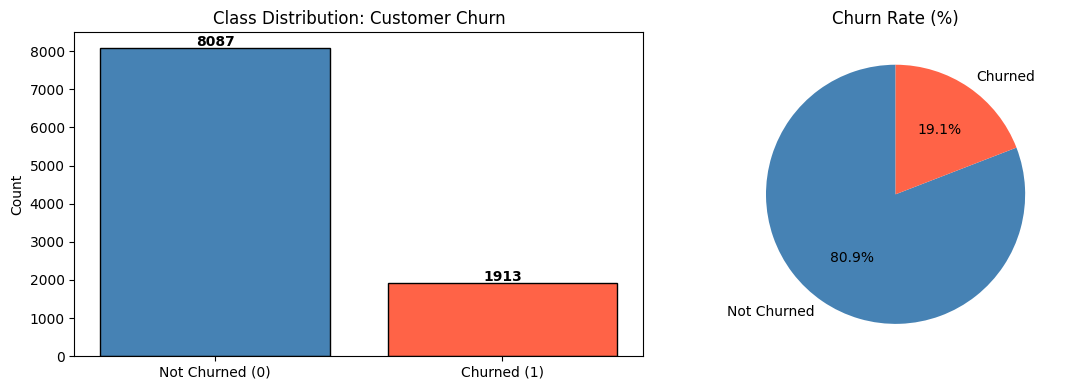


Churn Rate: 19.1%
⚠️ Note: Imbalanced dataset — accuracy alone is misleading!
   A model predicting 'never churn' gets ~80% accuracy but is useless.
   Use Precision, Recall, and F1-Score for proper evaluation.


In [4]:
# Class distribution — How balanced is the target?
churn_counts = df['Exited'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Not Churned (0)', 'Churned (1)'], churn_counts.values,
            color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title("Class Distribution: Customer Churn")
axes[0].set_ylabel("Count")
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

axes[1].pie(churn_counts.values, labels=['Not Churned', 'Churned'],
            autopct='%1.1f%%', colors=['steelblue', 'tomato'], startangle=90)
axes[1].set_title("Churn Rate (%)")

plt.tight_layout()
plt.show()

print(f"\nChurn Rate: {churn_counts[1]/len(df)*100:.1f}%")
print("⚠️ Note: Imbalanced dataset — accuracy alone is misleading!")
print("   A model predicting 'never churn' gets ~80% accuracy but is useless.")
print("   Use Precision, Recall, and F1-Score for proper evaluation.")

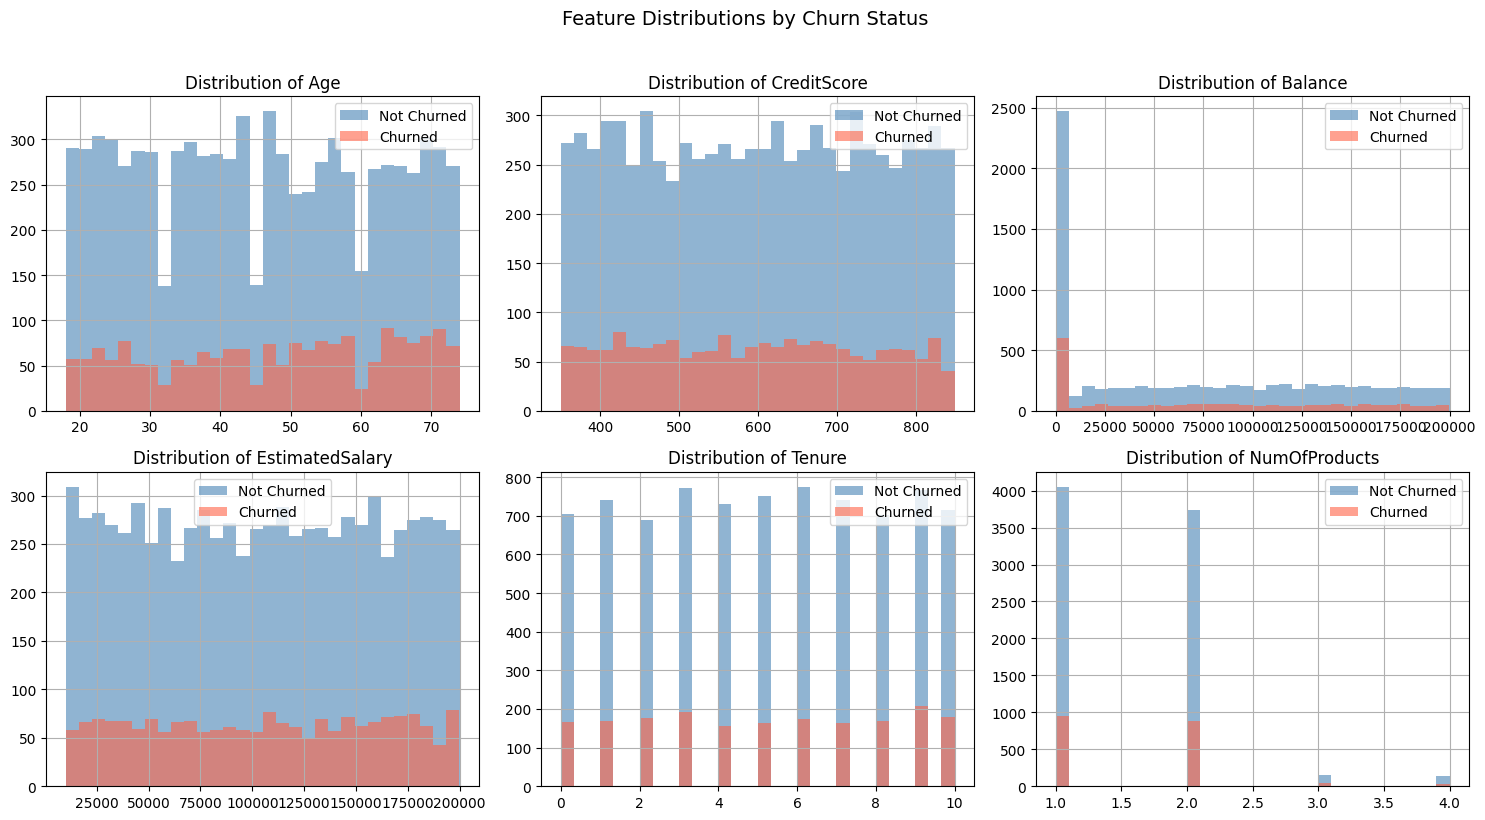

In [5]:
# Feature analysis
fig, axes = plt.subplots(2, 3, figsize=(15, 8)) #2 rows 3 column
numerical_features = ['Age', 'CreditScore', 'Balance', 'EstimatedSalary', 'Tenure', 'NumOfProducts']

for ax, feat in zip(axes.flatten(), numerical_features):
    df[df['Exited'] == 0][feat].hist(ax=ax, alpha=0.6, color='steelblue', bins=30, label='Not Churned')
    df[df['Exited'] == 1][feat].hist(ax=ax, alpha=0.6, color='tomato', bins=30, label='Churned')
    ax.set_title(f'Distribution of {feat}')
    ax.legend()

plt.suptitle("Feature Distributions by Churn Status", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 🛠️ Step 4: Data Preprocessing

### Steps:
1. **Drop irrelevant columns** (ID, Name, Row Number)
2. **Encode categorical variables** (Gender → 0/1, Geography → One-Hot)
3. **Feature Scaling** — Standardize numerical features to mean=0, std=1
4. **Train/Test Split** — 80% training, 20% testing

In [6]:
# Step 4.1: Drop non-informative columns
df_clean = df.drop(columns=['RowNumber', 'CustomerId', 'Surname']) #droping the noe required features
print("Dropped: RowNumber, CustomerId, Surname (no predictive value)")

# Step 4.2: Encode Gender (Binary Encoding)
# Male → 1, Female → 0
le = LabelEncoder()
df_clean['Gender'] = le.fit_transform(df_clean['Gender'])
print("Gender encoded: Male=1, Female=0")

# Step 4.3: One-Hot Encode Geography
# Geography has 3 categories → 3 binary columns
# drop_first=True avoids the 'dummy variable trap' (multicollinearity)
df_clean = pd.get_dummies(df_clean, columns=['Geography'], drop_first=False)
print("Geography one-hot encoded into separate binary columns")

print(f"\nFinal features: {list(df_clean.columns)}")
print(f"Dataset shape after encoding: {df_clean.shape}")
df_clean.head(3)

Dropped: RowNumber, CustomerId, Surname (no predictive value)
Gender encoded: Male=1, Female=0
Geography one-hot encoded into separate binary columns

Final features: ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_France', 'Geography_Germany', 'Geography_Spain']
Dataset shape after encoding: (10000, 13)


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
0,397,0,44,7,125488.031231,2,1,1,160622.766798,0,True,False,False
1,400,1,30,6,111410.476036,1,0,0,73883.006691,0,False,True,False
2,648,1,41,3,153503.641262,2,0,0,30376.905299,1,True,False,False


In [7]:
# Step 4.4: Separate features and target
X = df_clean.drop('Exited', axis=1).values
y = df_clean['Exited'].values

# Step 4.5: Train/Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # stratify ensures same class ratio
)

# Step 4.6: Feature Scaling (Standardization)
# Z = (X - mean) / std  →  output has mean≈0, std≈1
# IMPORTANT: Fit scaler ONLY on training data to prevent data leakage!
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)  # Fit + Transform
X_test = scaler.transform(X_test)        # Only Transform (no re-fitting!)

print("Data Preprocessing Complete!")
print(f"  Training samples: {X_train.shape[0]}")
print(f"  Test samples:     {X_test.shape[0]}")
print(f"  Features per sample: {X_train.shape[1]}")
print(f"\n  Train churn rate: {y_train.mean()*100:.1f}%")
print(f"  Test churn rate:  {y_test.mean()*100:.1f}%")

Data Preprocessing Complete!
  Training samples: 8000
  Test samples:     2000
  Features per sample: 12

  Train churn rate: 19.1%
  Test churn rate:  19.1%


## 🏗️ Step 5: Build the Deep MLP Model

### Architecture:
```
Input (12 features)
  → Dense(64, ReLU) + Dropout(0.3)
  → Dense(32, ReLU) + Dropout(0.3)
  → Dense(16, ReLU)
  → Dense(8, ReLU)
  → Dense(1, Sigmoid)  ← Output probability of churn
```

In [8]:
def build_deep_mlp(input_dim):
    """
    Build a deep MLP for binary classification.

    Design choices:
    - ReLU activation: avoids vanishing gradients (unlike Sigmoid in hidden layers)
    - Dropout: regularization to prevent overfitting
    - Sigmoid output: maps to probability [0, 1]
    - Binary cross-entropy loss: standard for binary classification
    - Adam optimizer: adaptive learning rate, generally best starting point
    """
    model = keras.Sequential([
        # Layer 1: Input + first hidden layer
        layers.Dense(64, activation='relu', input_shape=(input_dim,),
                     name='hidden_1'),
        layers.Dropout(0.3, name='dropout_1'),  # Drop 30% of neurons randomly during training

        # Layer 2: Second hidden layer
        layers.Dense(32, activation='relu', name='hidden_2'), #relu activation function
        layers.Dropout(0.3, name='dropout_2'),

        # Layer 3: Third hidden layer
        layers.Dense(16, activation='relu', name='hidden_3'),

        # Layer 4: Fourth hidden layer
        layers.Dense(8, activation='relu', name='hidden_4'),

        # Output layer: Single neuron with Sigmoid
        layers.Dense(1, activation='sigmoid', name='output')
    ])

    # Compile: specify optimizer, loss, and metrics
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model


# Build model
model = build_deep_mlp(input_dim=X_train.shape[1])

# Print summary — shows layers, output shapes, and parameter counts
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 64)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_3 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_4 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,585 (14.00 KB)

 Trainable params: 3,585 (14.00 KB)

 Non-trainable params: 0 (0.00 B)

## 🚀 Step 6: Train the Model

In [13]:
# Early stopping: stop training when validation loss stops improving
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,           # Wait 10 epochs before stopping
    restore_best_weights=True  # Revert to best model weights
)

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=100,            # Max epochs
    batch_size=32,         # Samples per gradient update
    validation_split=0.2,  # 20% of training data used for validation
    callbacks=[early_stop],
    verbose=1
)

print(f"\nTraining stopped at epoch: {len(history.history['loss'])}")

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8069 - loss: 0.4753 - val_accuracy: 0.8163 - val_loss: 0.4788
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8069 - loss: 0.4732 - val_accuracy: 0.8163 - val_loss: 0.4769
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8069 - loss: 0.4728 - val_accuracy: 0.8163 - val_loss: 0.4765
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8069 - loss: 0.4723 - val_accuracy: 0.8163 - val_loss: 0.4760
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8069 - loss: 0.4751 - val_accuracy: 0.8163 - val_loss: 0.4777
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8069 - loss: 0.4721 - val_accuracy: 0.8163 - val_loss: 0.4766
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8069 - loss: 0.4719 - val_accuracy: 0.8163 - val_loss: 0.4745
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8069 - loss: 0.4730 - val_accu

## 📈 Step 7: Visualize Training History

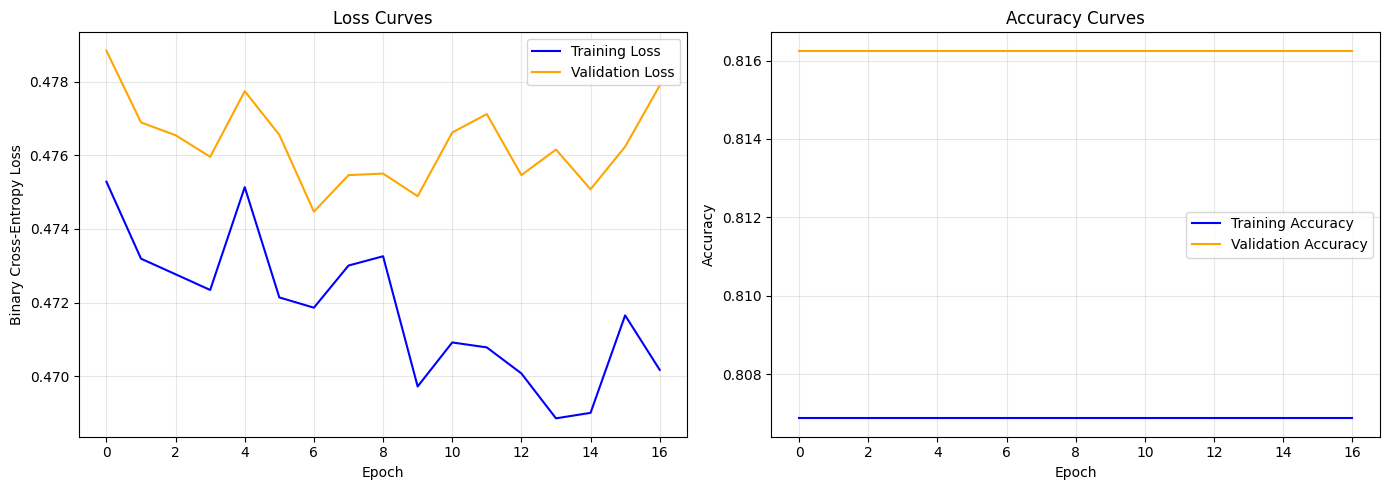

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(history.history['loss'], label='Training Loss', color='blue')
axes[0].plot(history.history['val_loss'], label='Validation Loss', color='orange')
axes[0].set_title("Loss Curves")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Binary Cross-Entropy Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy curves
axes[1].plot(history.history['accuracy'], label='Training Accuracy', color='blue')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
axes[1].set_title("Accuracy Curves")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
#by analysing we can say that loss decreasing after each epoch and accuracy increasing slightly

## ✅ Step 8: Evaluate with Industry-Standard Metrics

### Why not just use Accuracy?
With 80% non-churn rate, a dummy model predicting 'no churn' always gets **80% accuracy** — useless!

| Metric | Formula | Meaning |
|--------|---------|--------|
| **Precision** | TP / (TP + FP) | Of all predicted churners, how many actually churned? |
| **Recall** | TP / (TP + FN) | Of all actual churners, how many did we catch? |
| **F1-Score** | 2 × (P × R) / (P + R) | Harmonic mean of Precision and Recall |

In [11]:
# Generate predictions
y_prob = model.predict(X_test).flatten()
y_pred = (y_prob >= 0.5).astype(int)

# Compute metrics
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
accuracy  = np.mean(y_pred == y_test)

print("=" * 45)
print("  EVALUATION RESULTS ON TEST SET")
print("=" * 45)
print(f"  Accuracy  : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print("=" * 45)

# Detailed report
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Not Churned', 'Churned']))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
  EVALUATION RESULTS ON TEST SET
  Accuracy  : 0.8085  (80.85%)
  Precision : 0.0000
  Recall    : 0.0000
  F1-Score  : 0.0000

Detailed Classification Report:
              precision    recall  f1-score   support

 Not Churned       0.81      1.00      0.89      1617
     Churned       0.00      0.00      0.00       383

    accuracy                           0.81      2000
   macro avg       0.40      0.50      0.45      2000
weighted avg       0.65      0.81      0.72      2000



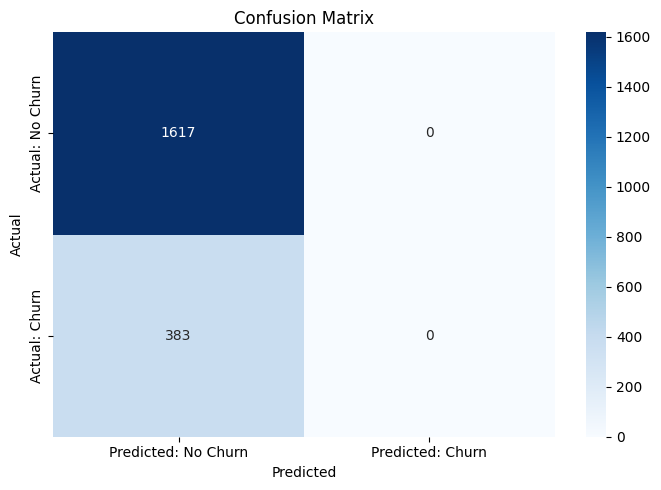

True Negatives (TN): 1617  — Correctly predicted No Churn
False Positives (FP): 0  — Incorrectly flagged as Churn (Type I Error)
False Negatives (FN): 383  — Missed actual churners (Type II Error — costly!)
True Positives (TP): 0  — Correctly predicted Churn


In [12]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: No Churn', 'Predicted: Churn'],
            yticklabels=['Actual: No Churn', 'Actual: Churn'])
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives (TN): {tn}  — Correctly predicted No Churn")
print(f"False Positives (FP): {fp}  — Incorrectly flagged as Churn (Type I Error)")
print(f"False Negatives (FN): {fn}  — Missed actual churners (Type II Error — costly!)")
print(f"True Positives (TP): {tp}  — Correctly predicted Churn")

---

## 📝 Summary

| Step | Action | Why |
|------|--------|-----|
| Drop columns | Remove ID/Name | No predictive signal |
| Label Encoding | Gender → 0/1 | Binary category |
| One-Hot Encoding | Geography → 3 columns | Avoid ordinal assumption |
| StandardScaler | Normalize features | Gradient descent converges faster |
| Stratified Split | Maintain class ratio | Fair evaluation |
| Dropout | Randomly drop neurons | Prevent overfitting |
| F1-Score | Harmonic mean P & R | Best metric for imbalanced data |

---

## ❓ Viva / Self-Check Questions

1. **Why is accuracy a misleading metric for imbalanced datasets?** Give a specific example using numbers.

2. **What is the difference between Precision and Recall?** For a bank trying to retain customers, which metric is more important — high Precision or high Recall? Justify your answer.

3. **What is the 'Dummy Variable Trap'?** Why do we use `drop_first=True` in One-Hot Encoding?

4. **Why do we fit the StandardScaler only on training data and not on test data?** What is the concept of 'data leakage'?

5. **What is Dropout regularization?** How does it prevent overfitting?

6. **What is Early Stopping?** How does it use the validation loss to prevent overfitting?

7. **ReLU is used in hidden layers but Sigmoid is used in the output layer. Why not use Sigmoid everywhere?**

8. **What is the F1-Score?** Why is it called the 'harmonic mean' and not the 'arithmetic mean' of Precision and Recall?